# Assignment 7 - Logistic Regression (Iris Dataset)

This notebook performs multi-class classification using Logistic Regression on the Iris dataset.

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

In [86]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [87]:
df.shape

(150, 6)

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_name        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 8.4 KB


In [89]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


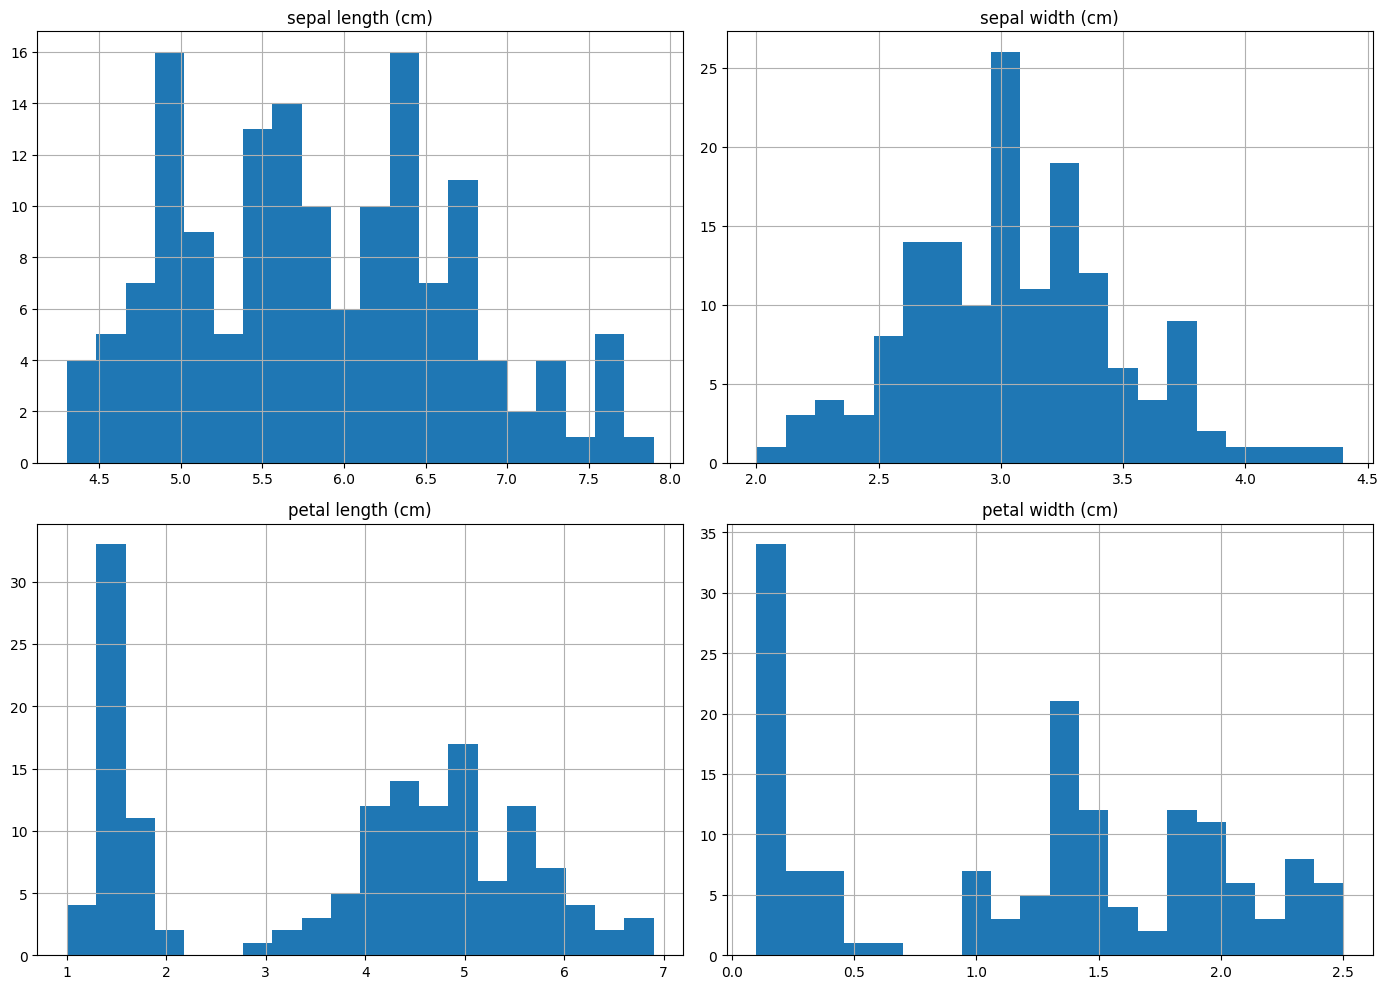

In [90]:
df.drop(['target', 'target_name'], axis=1).hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

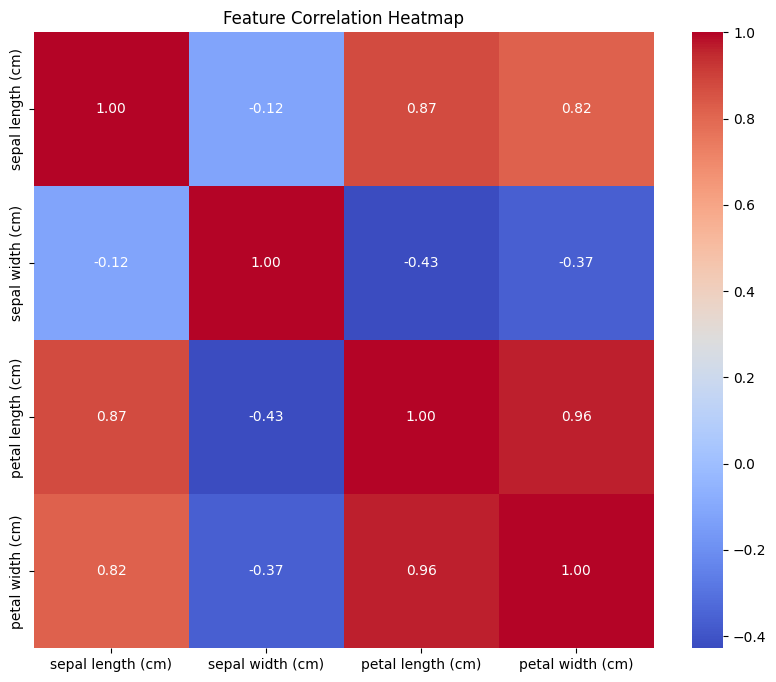

In [91]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(['target', 'target_name'], axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [92]:
X = df.drop(['target', 'target_name'], axis=1)
y = df['target']

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=105, stratify=y
)

In [94]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [95]:
import warnings

warnings.filterwarnings(
    'ignore',
    category=FutureWarning,
    message=r".*'penalty' was deprecated.*"
 )

lr = LogisticRegression(max_iter=1000)

parameter = [
    {'penalty': ['l2'], 'solver': ['lbfgs', 'saga'], 'C': [1, 2, 3, 4, 5]},
    {'penalty': [None], 'solver': ['lbfgs', 'saga'], 'C': [1]},
]

grid = GridSearchCV(lr, param_grid=parameter, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print('Best Parameters:', grid.best_params_)
print('Best CV Score:', grid.best_score_)

Best Parameters: {'C': 1, 'penalty': None, 'solver': 'lbfgs'}
Best CV Score: 0.9458498023715414


/Users/anshumaansoni/PycharmProjects/Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/anshumaansoni/PycharmProjects/Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/anshumaansoni/PycharmProjects/Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/anshumaansoni/PycharmProjects/Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [96]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print('Accuracy :', accuracy)
print('Precision:', precision)
print('Recall   :', recall)
print('F1 Score :', f1)

Accuracy : 0.9736842105263158
Precision: 0.9755639097744361
Recall   : 0.9736842105263158
F1 Score : 0.973599457581151


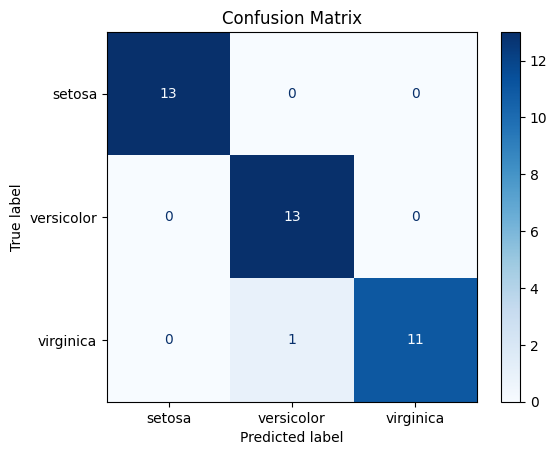

In [97]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['setosa', 'versicolor', 'virginica'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [98]:
print(classification_report(y_test, y_pred, target_names=['setosa', 'versicolor', 'virginica']))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        12

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38

